# Benchmark: PXD014777 HeLa 10 replicate dataset

Let's start with the imports.

In [8]:
%%capture

%matplotlib inline
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import umap
import seaborn as sns

import pipp
import pipp.utils

np.random.seed(0)

Let's define the paths to the data and the pretrained model.

In [9]:
PRETRAINED_MODEL_PATH = "../../checkpoints/PXD019086_PXD010012_combined_evidence_90Kto20Ksplit_5query_1shot_fullmodel_featuresScaled_allPeptidesTxtFeatures_modSeqSpecies_hidden64_latent10_maxEpoch300_164trainways_xlatent_conditionalEmbedding.pth"

HELA_MS1_OUT_PATH = "../../data/PXD014777/processed/hela_ms1.csv"
HELA_MS2_OUT_PATH = "../../data/PXD014777/processed/hela_ms2.csv"
SPECIES_MS2_OUT_PATH = "../../data/PXD014777/processed/species_ms2.csv"

In [10]:
df_ms1_hela = pd.read_csv(HELA_MS1_OUT_PATH)
df_ms2_hela = pd.read_csv(HELA_MS2_OUT_PATH)
df_ms2_species = pd.read_csv(SPECIES_MS2_OUT_PATH)

/var/folders/dj/lbjr_33912s45mqrggv2hz9m0000gn/T/ipykernel_78611/1735780731.py:2: DtypeWarning: Columns (61,69) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ms2_hela = pd.read_csv(HELA_MS2_OUT_PATH)
/var/folders/dj/lbjr_33912s45mqrggv2hz9m0000gn/T/ipykernel_78611/1735780731.py:3: DtypeWarning: Columns (61,69) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ms2_species = pd.read_csv(SPECIES_MS2_OUT_PATH)


## PIPP model

### Computing the Embeddings

Let's load the model and compute the embeddings.

In [11]:
features = [
    "Charge",
    "Mass",
    "m/z",
    "Retention time",
    "Retention length",
    "Ion mobility index",
    "Ion mobility length",
    "Number of isotopic peaks",
]

In [12]:
model = pipp.Peptideprotonet.load(PRETRAINED_MODEL_PATH)

In [13]:
ms1_embeddings = model.get_latent_representations(df_ms1_hela[features])

In [14]:
ms2_embeddings = model.get_latent_representations(df_ms2_hela[features])

In [15]:
ms1_embeddings = ms1_embeddings - np.mean(ms1_embeddings, axis=0)
ms2_embeddings = ms2_embeddings - np.mean(ms2_embeddings, axis=0)

Let's look at the embedding space.
We'll look at a subset of peptides due to memory limitations.

In [16]:
n = 50_000
random_indices = np.random.choice(range(len(ms2_embeddings)), size=n, replace=False)

Let's also add some "random" peptides to ensure all possible runs of at least a few peptides are included.

In [17]:
high_coverage_peptides_to_include = [
    '_(ac)AAAAAAAAAAGAAGGR_2',
    '_LGMENDDTAVQYAIGR_2',
    '_LGHVVMGNNAVSPYQQVIEK_2',
    '_LEEVLSTEGAEENGNSDK_2',
    '_PAPQMNGSTGDAR_2',
    '_HLQINQTFEELR_2',
    '_LLAGEDGTSER_2',
    '_LETMPLYLEDDIRPDIK_3',
    '_LFNDSSPVVLEESWDALNAITK_3',
]

low_coverage_peptides_to_include = [
    '_ELFEQYGAVYEINVLR_3',
    '_ELFDELVK_2',
    '_FLGDYVENLNK_2',
    '_HHSQQAPQAEAPCLLR_3',
    '_HFSTTTNNIQSR_2',
    '_LEEIAELVASSLPSPLR_3',
    '_AVLEQFGFPLTGTEAR_2',
    '_VPQFSFLDIFPK_2',
    '_VGPYHNPQETYHYYQLPVCCPEK_3',
    '_FDSASSSYYLDMHSLPHVINPVESR_4',
]

peptides_to_include = high_coverage_peptides_to_include + low_coverage_peptides_to_include

custom_indices = [df_ms2_hela.index[df_ms2_hela['PrecursorID'] == peptide].tolist() for peptide in peptides_to_include]
custom_indices = [peptide for peptide_runs in custom_indices for peptide in peptide_runs]
custom_indices = [df_ms2_hela.index.get_loc(i) for i in custom_indices]

# print(peptides_abundances)

In [18]:
indices = np.unique(np.concatenate((random_indices, custom_indices)))

In [19]:
df_ms2_hela_subset = df_ms2_hela.iloc[indices]
ms2_embeddings_subset = ms2_embeddings[indices]

Let's compute the UMAP for plotting.

In [20]:
reducer = umap.UMAP(metric = 'cosine')
umap_embedding = reducer.fit_transform(ms2_embeddings_subset)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


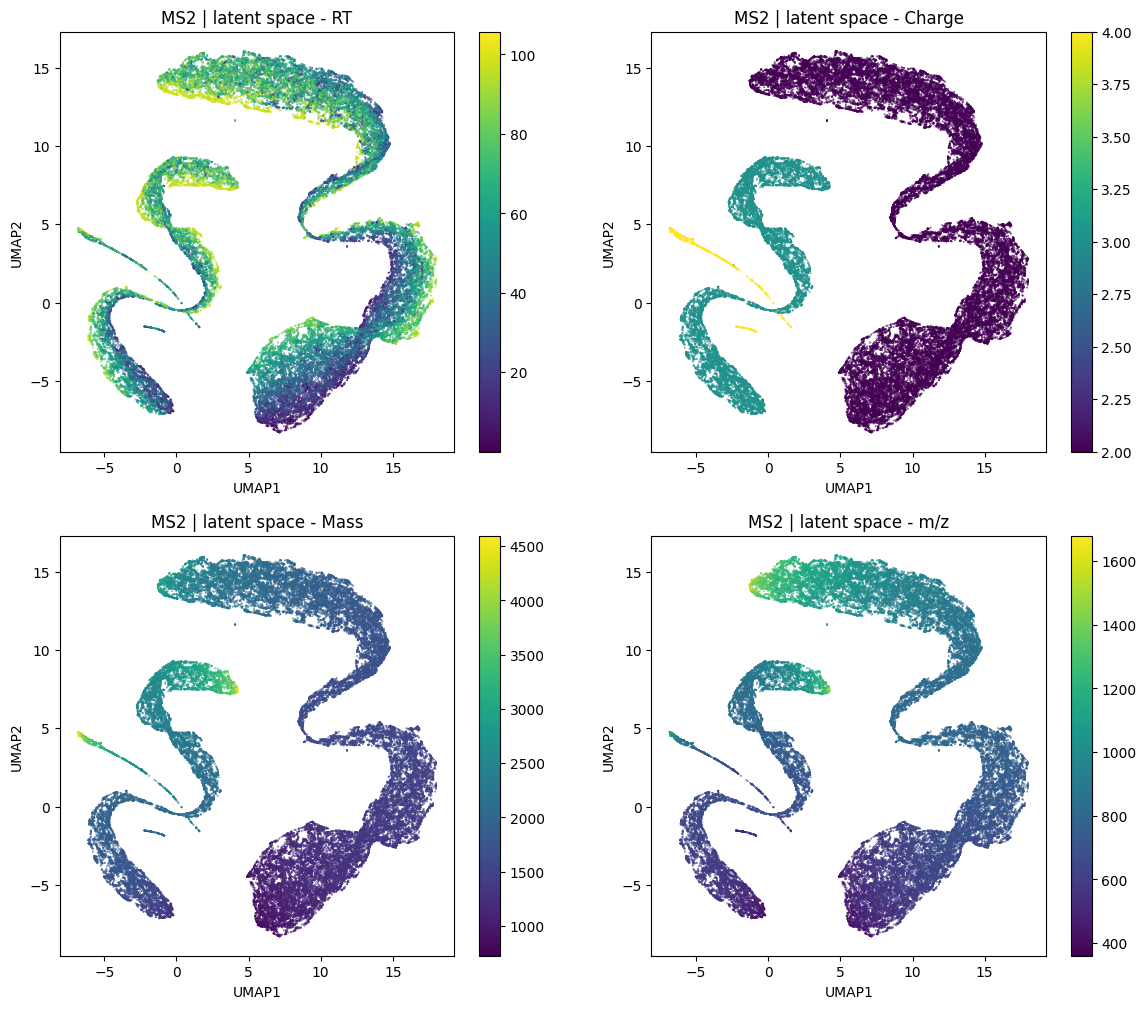

In [21]:
fig, axs = plt.subplots(figsize=(14, 12), ncols=2, nrows=2)

ax = axs[0][0]
sp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=df_ms2_hela_subset['Retention time'], s=0.1)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - RT')
fig.colorbar(sp)

ax = axs[0][1]
sp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=df_ms2_hela_subset['Charge'], s=0.1)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - Charge')
fig.colorbar(sp)

ax = axs[1][0]
sp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=df_ms2_hela_subset['Mass'], s=0.1)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - Mass')
fig.colorbar(sp)

ax = axs[1][1]
sp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=df_ms2_hela_subset['m/z'], s=0.1)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - m/z')
fig.colorbar(sp)

Let's also plot the latent space of the MS2 data together with some low coverage and high coverage peptides.

In [16]:
peptide_abundances = df_ms2_hela["PrecursorID"].value_counts()

Text(0.5, 1.0, 'MS2 | latent space - low coverage peptides')

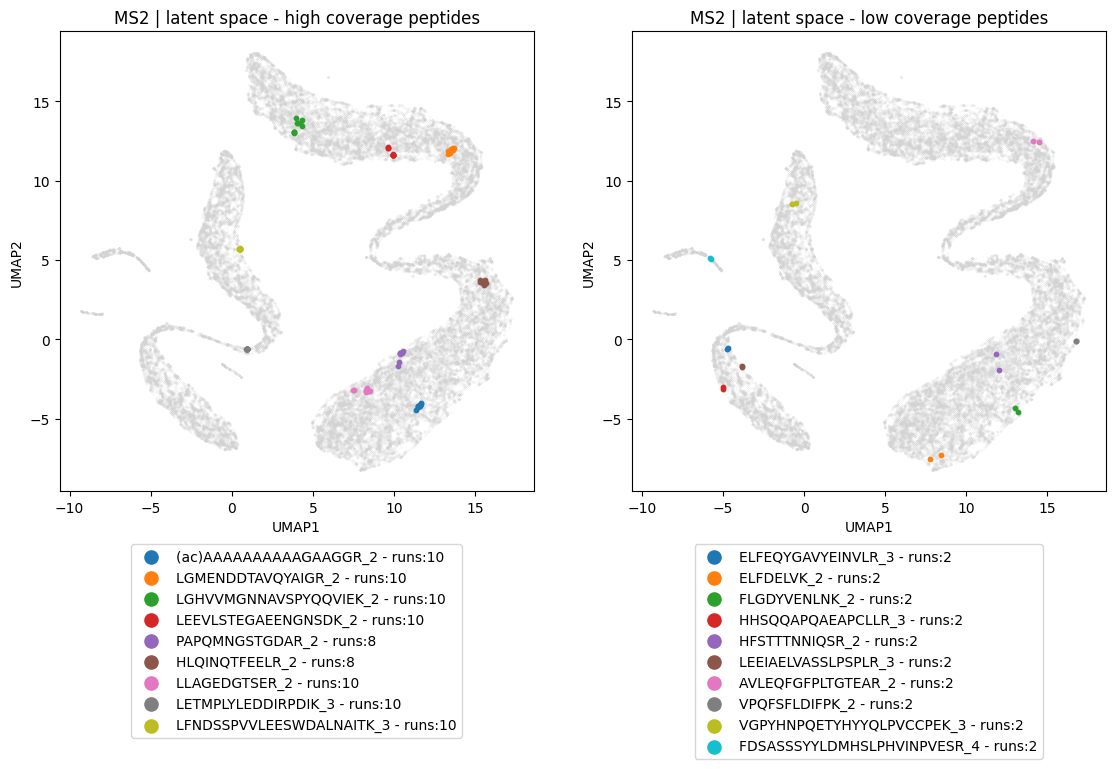

In [17]:
fig, axs = plt.subplots(figsize=(12, 6), ncols=2, nrows=1)
fig.tight_layout(pad=4.0)

# high coverage peptides
ax = axs[0]
ax.scatter(umap_embedding[:,0], umap_embedding[:,1], s=0.01, color='lightgrey')

for i, peptide in enumerate(high_coverage_peptides_to_include):
    peptide_ref_indices = np.where(df_ms2_hela_subset['PrecursorID'] == peptide)
    ax.scatter(umap_embedding[peptide_ref_indices,0], umap_embedding[peptide_ref_indices,1], s=10, color=plt.cm.tab10(i), label=f"{peptide[1:]} - runs:{peptide_abundances[peptide]}")

ax.legend(markerscale=3, loc='upper center', bbox_to_anchor=(0.5, -0.1))
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - high coverage peptides')

# low coverage peptides
ax = axs[1]
ax.scatter(umap_embedding[:,0], umap_embedding[:,1], s=0.01, color='lightgrey')

for i, peptide in enumerate(low_coverage_peptides_to_include):
    peptide_ref_indices = np.where(df_ms2_hela_subset['PrecursorID'] == peptide)
    ax.scatter(umap_embedding[peptide_ref_indices,0], umap_embedding[peptide_ref_indices,1], s=10, color=plt.cm.tab10(i), label=f"{peptide[1:]} - runs:{peptide_abundances[peptide]}")

ax.legend(markerscale=3, loc='upper center', bbox_to_anchor=(0.5, -0.1))
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - low coverage peptides')

## Peptide Identity Propagation

### Identification on the MS1 data

In [22]:
ms1_only_locs = df_ms1_hela.index.difference(df_ms2_hela.index)
ms1_only_ilocs = df_ms1_hela.index.get_indexer(ms1_only_locs)

In [23]:
ms1_only = df_ms1_hela.iloc[ms1_only_ilocs]

In [30]:
k_neighbours = 15
esm2_model = "esm2_t6_8M_UR50D"
n_representation_layer = 6
n_anchor=5
n_pc=5
use_precomputed_esm_embeddings = False
esm_embedding_path = f'../../PXD014777/embeddings/{esm2_model}_layer{n_representation_layer}_datasetHeLa.npy'

identifications, confidence = model.propagate(
    ms1_only,
    df_ms2_hela,
    k_neighbours=k_neighbours,
    esm2_model=esm2_model,
    n_representation_layer=n_representation_layer,
    n_anchors=n_anchor,
    n_principal_components=n_pc,
    esm_embedding_path=esm_embedding_path,
    )

computing prototypes...
ESM-2 embeddings of peptide sequences already computed: 0
ESM-2 embeddings of peptide sequences already computed: 512
ESM-2 embeddings of peptide sequences already computed: 1024
ESM-2 embeddings of peptide sequences already computed: 1536
ESM-2 embeddings of peptide sequences already computed: 2048
ESM-2 embeddings of peptide sequences already computed: 2560
ESM-2 embeddings of peptide sequences already computed: 3072
ESM-2 embeddings of peptide sequences already computed: 3584
ESM-2 embeddings of peptide sequences already computed: 4096
ESM-2 embeddings of peptide sequences already computed: 4608
ESM-2 embeddings of peptide sequences already computed: 5120
ESM-2 embeddings of peptide sequences already computed: 5632
ESM-2 embeddings of peptide sequences already computed: 6144
ESM-2 embeddings of peptide sequences already computed: 6656
ESM-2 embeddings of peptide sequences already computed: 7168
ESM-2 embeddings of peptide sequences already computed: 7680
ESM-

In [21]:
'''Specifies how many closest neighbours are computed for each query precursor.
Would it be sufficient to always choose 1?'''
k_neighbours = 15

'''Specifies the ESM-2 model. The following models are available and are downloaded in the first use. 
    - "esm2_t6_8M_UR50D": 6 layers, 8 million parameters, 320-dim embedding
    - "esm2_t12_35M_UR50D": 12 layers, 35 million parameters, 480-dim embedding
    - "esm2_t30_150M_UR50D": 30 layers, 150 million parameters, 640-dim embedding
    - "esm2_t33_650M_UR50D": 33 layers, 650 million parameters, 1280-dim embedding
    - "esm2_t36_3B_UR50D": : 36 layers, 3 billion parameters, 2560-dim embedding, 6GB size
    - "esm2_t48_15B_UR50D": 48 layers, 15 billion parameters, 5120-dim embedding, 30GB size
In the model names, the number after the "t" stands for the total layer number.
The next number stands for the parameter number.
"UR50D" stands for the used training dataset of the ESM-2 model which is UniRef 50.
'''
esm2_model = "esm2_t6_8M_UR50D"

'''Specifies the ESM-2 layer from which the representations should be taken'''
n_representation_layer = 6

n_anchor=5

n_pc=5

'''Specifies whether to use ESM-2 embeddings that have already been computed.
If True, then the location needs to be specified below.'''
use_precomputed_esm_embeddings = True

'''Specifies the relative path to the precomputed ESM-2 embeddings'''
esm_embedding_path = f'../../PXD014777/embeddings/{esm2_model}_layer{n_representation_layer}_datasetHeLa.npy'

identifications, confidence = model.propagate(
    ms1_only,
    df_ms2_hela,
    k_neighbours=k_neighbours,
    esm2_model=esm2_model,
    n_representation_layer=n_representation_layer,
    n_anchors=n_anchor,
    n_principal_components=n_pc,
    use_precomputed_esm_embeddings=use_precomputed_esm_embeddings,
    esm_embedding_path=esm_embedding_path,
    dataset="HeLa")

computing prototypes...


FileNotFoundError: [Errno 2] No such file or directory: 'example_data/embeddings_esm2_t6_8M_UR50D_layer6_datasetHeLa_X.npy'

In [ ]:
print(f"Number of prototypes: {df_ms2_hela['PrecursorID'].nunique()}")

Let's plot the distribution of the confidence scores for the MS1 identifications. Additionally, we'll add a threshold to the plot, which we'll use to filter out low confidence identifications.

In [ ]:
confidence_threshold = 0.2

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(confidence, bins=80, color='blue', edgecolor='black', linewidth=1.2)
ax.set_xlabel('Confidence')
ax.set_ylabel('Number of peptides')
ax.set_title(f'Distribution of peptide confidence - knn={k_neighbours}')
ax.set_xlim([0, 1])
ax.grid(True)
ax.set_axisbelow(True)

ax.axvline(x=confidence_threshold, color='red', linestyle='--')
ax.axvline(x=1/k_neighbours, color='black', linestyle='--')
ax.axvspan(confidence_threshold, 1, alpha=0.1, color='red')

identified_count = np.sum(confidence > confidence_threshold)
ax.text(confidence_threshold + 0.01, 5e5, f'Peptides identified: {identified_count} ({identified_count / len(ms1_only) * 100:.2f}%)', color='red')

Let's plot the number of peptides identified for different thresholds.

In [ ]:
thresholds = np.linspace(0.3, 1, 50)
identified_counts = [np.sum(confidence > threshold) for threshold in thresholds]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(thresholds, identified_counts, color='blue', linewidth=1.2)

ax.set_xlabel('Confidence threshold')
ax.set_ylabel('Number of peptides identified')
ax.set_title(f'Number of peptides identified as a function of confidence threshold - knn={k_neighbours}')
ax.set_xlim([0, 1])
ax.grid(True)
ax.set_axisbelow(True)

ax2 = ax.twinx()
ax2.plot(thresholds, np.array(identified_counts) / len(ms1_only) * 100, color='red', linewidth=0) # @NOTE: linewidth=0 to hide the line
ax2.set_ylabel('Percentage of peptides identified (%)')

Let's generate a dataframe with the results combining both the MS1 (excluding the MS2 data entries) and MS2 data using the features: run (raw file), Intensity, precursorID, confidence. We'll use these features to generate the expression matrices (and heatmaps).


In [ ]:
ms1_expression_features = {
    'Raw file': ms1_only['Raw file'],
    'Intensities': ms1_only['Intensity'],
    'PrecursorID': identifications,
    'Confidence': confidence,
}

ms2_expression_features = {
    'Raw file': df_ms2_hela['Raw file'],
    'Intensities': df_ms2_hela['Intensity'],
    'PrecursorID': df_ms2_hela['PrecursorID'],
    'Confidence': np.ones(df_ms2_hela.shape[0]),
}


ms1_expression_features = pd.DataFrame(ms1_expression_features)
ms2_expression_features = pd.DataFrame(ms2_expression_features)

expression_features = pd.concat([ms1_expression_features, ms2_expression_features], ignore_index=False)

print(f'Expression matrix shape: {expression_features.shape}, MS1 shape: {ms1_expression_features.shape}, MS2 shape: {ms2_expression_features.shape}')

In [ ]:
ms1_expression_features.head()

NameError: name 'ms1_expression_features' is not defined

In [ ]:
ms2_expression_features.head()

NameError: name 'ms2_expression_features' is not defined

Due to the propagation, there may be entries with the same 'Raw file' and 'PrecursorID'. For these overlapping entries, only the entry with the largest intensity is kept when plotting the heatmap for the MS1 expression matrix.

First the expression matrix for the MS1 data (excluding the peptides identified in MS2) is created. We also filter low confidence identifications.

In [ ]:
confidence_threshold = 0.5

print(f"Number of peptides: {ms1_expression_features['PrecursorID'].nunique()}")

ms1_expression_features = ms1_expression_features.loc[ms1_expression_features.groupby(['Raw file', 'PrecursorID'])['Intensities'].idxmax()]
print(f"Number of peptides after max intensities: {ms1_expression_features['PrecursorID'].nunique()}")

ms1_expression_features = ms1_expression_features.loc[ms1_expression_features['Confidence'] > confidence_threshold]
print(f"Number of peptides after confidence threshold: {ms1_expression_features['PrecursorID'].nunique()}")

Let's look at the peptides that were identified in both MS1 and MS2 for the expression matrices.

In [ ]:
precursor_ids = ms1_expression_features[ms1_expression_features['PrecursorID'].isin(ms2_expression_features['PrecursorID'])]['PrecursorID'].unique()

In [ ]:
ms1_expression_features = ms1_expression_features[ms1_expression_features['PrecursorID'].isin(precursor_ids)].sort_values(by=['PrecursorID'])
ms1_expression = ms1_expression_features.pivot(index='PrecursorID', columns='Raw file', values='Intensities')

In [ ]:
ms1_expression.head()

Next, the expression matrix for the MS2 data is created:

In [ ]:
ms2_expression_features = ms2_expression_features[ms2_expression_features['PrecursorID'].isin(precursor_ids)].sort_values(by=['PrecursorID'])
ms2_expression = ms2_expression_features.pivot(index='PrecursorID', columns='Raw file', values='Intensities')

In [ ]:
ms2_expression.head()

Finally, let's create another expression matrix where missing entries in MS2 expression matrix is filled in with the MS1 expression matrix.

In [ ]:
expression_fill = ms2_expression.combine_first(ms1_expression)

In [ ]:
expression_fill.head()

Let's extract the peptides

Let's plot the heatmaps.

In [ ]:
M = 200
n = min(M, ms1_expression.shape[0], ms2_expression.shape[0])

fig, axs = plt.subplots(figsize=(14, 10), ncols=3, nrows=1)
fig.tight_layout(pad=1.0)

# MaxQuant
ax = axs[0]
sns.heatmap(np.log2(ms2_expression.iloc[:n] + 1), ax=ax, cmap='viridis', 
            xticklabels=False, yticklabels=False, cbar=False)
ax.set_title('MaxQuant')
ax.set_xlabel('Run')
ax.set_ylabel('Peptide')

# PIPP
ax = axs[1]
sns.heatmap(np.log2(ms1_expression.iloc[:n] + 1), ax=ax, cmap='viridis', 
            xticklabels=False, yticklabels=False, cbar=False)
ax.set_title('PIPP')
ax.set_xlabel('Run')
ax.set_ylabel('Peptide')

# PIPP + MaxQuant
ax = axs[2]
sns.heatmap(np.log2(expression_fill + 1), ax=ax, cmap='viridis',
            xticklabels=False, yticklabels=False, cbar=False)
ax.set_title('MaxQuant + PIPP')
ax.set_xlabel('Run')
ax.set_ylabel('Peptide')

In [ ]:
# Count NaN values per row
nan_count_before = ms2_expression.isnull().sum(axis=1)
nan_count_after = expression_fill.isnull().sum(axis=1)

# Calculate average NaN values per row
avg_nan_before = nan_count_before.mean()
avg_nan_after = nan_count_after.mean()

# Create a bar plot
fig, ax = plt.subplots()
ax.bar(['Before PIPP', 'After PIPP'], [avg_nan_before, avg_nan_after], color=['blue', 'orange'])
ax.set_ylabel('Average NaN Values per Peptide/Row')
ax.set_title('Comparison of Average NaN Values per Peptide/Row')
plt.show()

# Count NaN values per column
nan_count_before_c = ms2_expression.isnull().sum()
nan_count_after_c = expression_fill.isnull().sum()

# Create a bar plot
fig, ax = plt.subplots(figsize=(10, 6))

# Width of each bar
bar_width = 0.35

# Positions for bars
bar_positions_before_c = np.arange(len(nan_count_before_c))
bar_positions_after_c = bar_positions_before_c + bar_width

# Plot bars for each DataFrame
ax.bar(bar_positions_before_c, nan_count_before_c, width=bar_width, label='Before PIPP')
ax.bar(bar_positions_after_c, nan_count_after_c, width=bar_width, label='After PIPP')

# Set labels and title
ax.set_xticks(bar_positions_before_c + bar_width / 2)
ax.set_xticklabels(('Run 1','Run 2','Run 3','Run 4','Run 5','Run 6','Run 7','Run 8','Run 9','Run 10',))
ax.set_ylabel('Number of NaN Values')
ax.set_title('Comparison of NaN Values per Run')

# Add legend
ax.legend()

# Show the plot
plt.show()

In [ ]:
# In proportion to what?
    # - percentage of NaN values to all values per row
    # - percentage of total NaN values to all values
    # - percentage of total NaN values to all values per run

# Count total NaN values
total_nan_count_before = ms2_expression.isna().sum().sum()
total_nan_count_after = expression_fill.isna().sum().sum()

# Count all values
num_rows, num_columns = expression_fill.shape
total_value_count = num_rows * num_columns

# Proportion
prop_nan_before = total_nan_count_before / total_value_count
prop_nan_after = total_nan_count_after / total_value_count

# Create a bar plot
fig, ax = plt.subplots()
ax.bar(['Before PIPP', 'After PIPP'], [prop_nan_before, prop_nan_after], color=['blue', 'orange'])
ax.set_ylabel('Proportion of NaN Values')
ax.set_title('Proportion of NaN values to all values across all runs and peptides')
plt.show()

# Count NaN values per row
nan_count_before = ms2_expression.isnull().sum(axis=1)
nan_count_after = expression_fill.isnull().sum(axis=1)

# Proportion
prop_row_before = nan_count_before / expression_fill.shape[1]
prop_row_after = nan_count_after / expression_fill.shape[1]

# Mean of proportion over rows
mean_prop_before = np.mean(prop_row_before)
mean_prop_after = np.mean(prop_row_after)

# Create a bar plot
fig, ax = plt.subplots()
ax.bar(['Before PIPP', 'After PIPP'], [mean_prop_before, mean_prop_after], color=['blue', 'orange'])
ax.set_ylabel('Mean proportion of NaN Values')
ax.set_title('Mean of proportion of NaN values per Peptide/Row')
plt.show()

# Calculate average NaN values per row
avg_nan_before = nan_count_before.mean()
avg_nan_after = nan_count_after.mean()

# Count NaN values per column
nan_count_before_c = ms2_expression.isnull().sum()
nan_count_after_c = expression_fill.isnull().sum()

# Proportion of NaN values per column
nan_prop_column_before = nan_count_before_c / expression_fill.shape[0]
nan_prop_column_after = nan_count_after_c / expression_fill.shape[0]

# Create a bar plot
fig, ax = plt.subplots(figsize=(10, 6))

# Width of each bar
bar_width = 0.35

# Positions for bars
bar_positions_before_c = np.arange(len(nan_count_before_c))
bar_positions_after_c = bar_positions_before_c + bar_width

# Plot bars for each DataFrame
ax.bar(bar_positions_before_c, nan_prop_column_before, width=bar_width, label='Before PIPP')
ax.bar(bar_positions_after_c, nan_prop_column_after, width=bar_width, label='After PIPP')

# Set labels and title
ax.set_xticks(bar_positions_before_c + bar_width / 2)
ax.set_xticklabels(('Run 1','Run 2','Run 3','Run 4','Run 5','Run 6','Run 7','Run 8','Run 9','Run 10',))
ax.set_ylabel('Proportion of NaN Values')
ax.set_title('Comparison of NaN Value Proportion per Run')

# Add legend
ax.legend()

# Show the plot
plt.show()

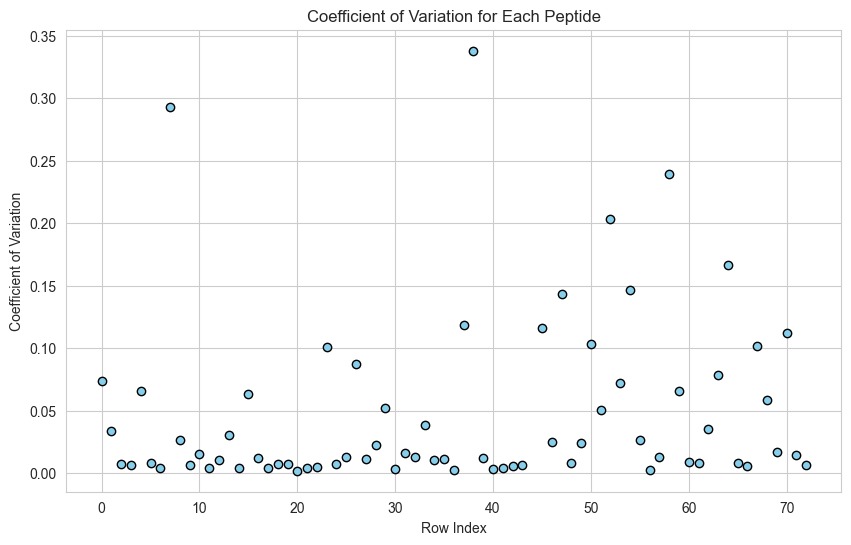

In [ ]:
# Log2 before CV calculation
expression_fill_log2 = np.log2(expression_fill)  

# Calculate the coefficient of variation for each row
cv_values = (expression_fill_log2.std(axis=1) / expression_fill_log2.mean(axis=1))

# Create a dot plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x=np.arange(len(cv_values)), y=cv_values, color='skyblue', edgecolor='black')

# Set labels and title
ax.set_xlabel('Row Index')
ax.set_ylabel('Coefficient of Variation')
ax.set_title('Coefficient of Variation for Each Peptide')

plt.show()

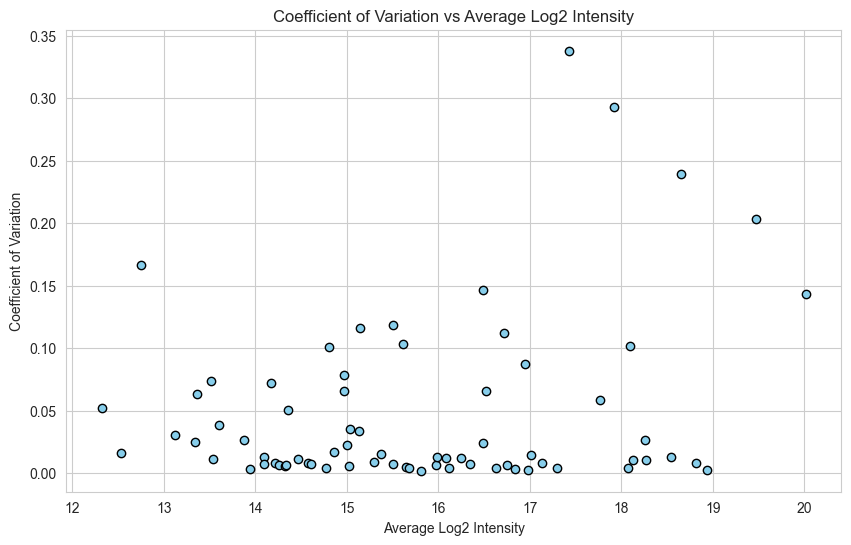

In [ ]:
# Log2 before CV calculation
expression_fill_log2 = np.log2(expression_fill)     

# Average Log2 intensity per row/peptide
log2_mean_per_peptide = expression_fill_log2.mean(axis=1)

# Calculate the coefficient of variation for each row
cv_values = (expression_fill_log2.std(axis=1) / expression_fill_log2.mean(axis=1))

cv_vs_log2 = pd.concat([log2_mean_per_peptide, cv_values], axis=1)

cv_vs_log2.columns = ['Log2', 'CV']

# Sort according to log2 intensity
cv_vs_log2 = cv_vs_log2.sort_values(by='Log2')

# Create a dot plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x=cv_vs_log2['Log2'], y=cv_vs_log2['CV'], color='skyblue', edgecolor='black')

# Set labels and title
ax.set_xlabel('Average Log2 Intensity')
ax.set_ylabel('Coefficient of Variation')
ax.set_title('Coefficient of Variation vs Average Log2 Intensity')

plt.show()

Let's compute the coefficient of variance for each peptide and plot it with the mean.

In [ ]:
expression_cv_features = expression_features[['PrecursorID', 'Intensities']].copy()
expression_cv_features['Intensities'] = np.log2(expression_cv_features['Intensities'] + 1)

expression_cv_features = expression_cv_features.groupby('PrecursorID').agg(['mean', 'std'])
expression_cv_features['CV'] = expression_cv_features['Intensities']['std'] / expression_cv_features['Intensities']['mean']
expression_cv_features['CV2'] = expression_cv_features['CV'] ** 2

In [ ]:
n = 10_000
random_indices = np.random.choice(range(len(expression_cv_features)), size=n, replace=False)

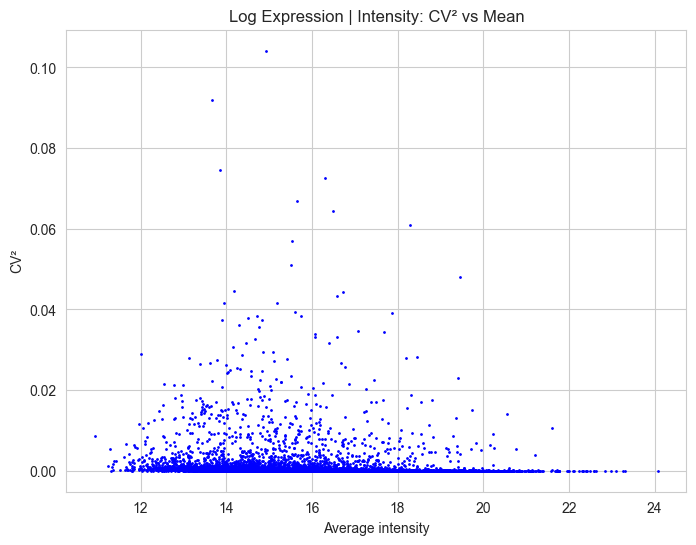

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(expression_cv_features['Intensities']['mean'].iloc[random_indices], expression_cv_features['CV2'].iloc[random_indices], s=1, color='blue')
ax.set_xlabel('Average intensity')
ax.set_ylabel('CV²')
ax.set_title('Log Expression | Intensity: CV² vs Mean')
ax.grid(True)
ax.set_axisbelow(True)

### Identification on held-out MS2 run

Let's hold out all the peptides in the MS2 dataset for a specific run and see how many of them are identified.

In [ ]:
runs = ms1_data['Raw file'].unique()

run_to_benchmark = runs[0]
print('Run to benchmark: {}'.format(run_to_benchmark))

other_runs = runs[runs != run_to_benchmark]

df_ms2_hela_subset = df_ms2_hela[df_ms2_hela['Raw file'] != run_to_benchmark]
ms2_embeddings_subset = ms2_embeddings[df_ms2_hela['Raw file'] != run_to_benchmark]

df_ms2_hela_benchmark = df_ms2_hela[df_ms2_hela['Raw file'] == run_to_benchmark].copy()
ms2_embeddings_benchmark = ms2_embeddings[df_ms2_hela['Raw file'] == run_to_benchmark]

Run to benchmark: 20190122_HeLa_QC_Slot1-47_1_3219


In [ ]:
k = 15

identities, confidence = model.propagate(df_ms2_hela_benchmark, df_ms2_hela_subset, k_neighbours=k)

computing prototypes...
Computing relative representations...


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 60544 and the array at index 1 has size 61517

In [ ]:
print(f"Number of prototypes: {df_ms2_hela_subset['PrecursorID'].nunique()}")

In [ ]:
df_ms2_hela_benchmark['Identification'] = identities
df_ms2_hela_benchmark['Identification Confidence'] = confidence

Let's plot the distribution of the confidence scores for the MS2 identifications. Additionally, we'll add a threshold to the plot, which we'll use to filter out low confidence identifications.

In [ ]:
peptide_threshold = 0.2


fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(df_ms2_hela_benchmark['Identification Confidence'], bins=80, color='blue', edgecolor='black', linewidth=1.2)
ax.set_xlabel('Confidence')
ax.set_ylabel('Number of peptides')
ax.set_title(f'Distribution of peptide confidence - knn={k}')
ax.set_xlim([0, 1])
ax.grid(True)
ax.set_axisbelow(True)

ax.axvline(x=peptide_threshold, color='red', linestyle='--')
ax.axvline(x=1/k, color='black', linestyle='--')
ax.axvspan(peptide_threshold, 1, alpha=0.1, color='red')

benchmark_threshold = df_ms2_hela_benchmark[df_ms2_hela_benchmark['Identification Confidence'] > peptide_threshold]
matches = np.sum(benchmark_threshold['PrecursorID'] == benchmark_threshold['Identification'])

identified_count = np.sum(df_ms2_hela_benchmark['Identification Confidence'] > peptide_threshold)
ax.text(peptide_threshold + 0.01, 5000, f'Peptides identified correctly: {matches} ({matches / benchmark_threshold.shape[0] * 100:.2f}%)', color='red')

Let's plot the number of peptides identified correctly for different thresholds.

In [ ]:
thresholds = np.linspace(1/k*2, 1, 50)
identified_counts = []
correct_counts = []

for threshold in thresholds:
    benchmark_threshold = df_ms2_hela_benchmark[df_ms2_hela_benchmark['Identification Confidence'] > threshold]
    matches = np.sum(benchmark_threshold['PrecursorID'] == benchmark_threshold['Identification'])
    identified_counts.append(benchmark_threshold.shape[0])
    correct_counts.append(matches)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(thresholds, identified_counts, color='red', linewidth=1.2, label='Identified peptides')
ax.plot(thresholds, correct_counts, color='blue', linewidth=1.2, linestyle='--', label='Correctly identified peptides')
ax.set_xlabel('Confidence threshold')
ax.set_ylabel('Number of peptides')
ax.set_title(f'Number of peptides identified correctly as a function of confidence threshold - knn={k}')
ax.set_xlim([0, 1])
ax.grid(True)
ax.set_axisbelow(True)
ax.legend()